# **<p align="center"> Ligand Occupancy </p>**

## <ins> Description </ins>
### The goal of this notebook is to identify if there is any correlation / information between the ligand occupancy in the crystal and its binding affinity

<details open>
<summary> <font size="6"> <ins>Key Points 2 </ins> </font> </summary>

- bulletpoint1

-  bulletpoint1

- [link]()

- image1: <img src="" width = 50%>

</details>

</br>

<details open>
<summary> <font size = "6"> <ins> Key Points 2 </ins> </font> </summary>

- `bulletpoint1`


- `bulletpoint2`



</details>

</br>


---

In [177]:
# Load Key Libraries
from pathlib import Path
rootdir = Path("../../../..").resolve()
import sys
sys.path.insert(0, str(rootdir) )
from typing import Callable, Generator

import gemmi 
import parasail
import numpy as np
from rdkit import Chem
import matplotlib.pyplot as plt

from xaidar.data.molecModels import loadPDB
from xaidar.data.molecModels import get_pdb_stats, sele_pdb, sele_Lig, get_res_CoM
from xaidar.data.molecModels import flatten_pdb, sele_AA, createPDB, get_atom_coord

## Looking at the occupancy of the Ligands

In [178]:
# Load Fragalysis data (nonactivepdbs_dir, fragscreen_dir, piperid_dir, ...)

# 1. Loading Fragalyis data Root Directory
rootProjDir = rootdir / "data/ev2a/fragalysis"
fragalysisDir =  rootdir / "data/ev2a/fragalysis"

# 2. Load Fragalysis Protein Directories
nonactivepdbs_dir = fragalysisDir / "02-chemofint/nonactivesite"
fragscreen_dir = fragalysisDir / "02-chemofint/fragscreen"
piperid_dir = fragalysisDir / "02-chemofint/piperid"

### Extracting and Loading Piperidine Objects from PDBs

In [179]:
print( [ item.name for item in  piperid_dir.iterdir()])

['A7175a', 'A5039b', 'A5460a', 'A4035b', 'A5424a', 'A4035a', 'A5247b', 'A3616b', 'A5052a', 'A4980a', 'A5393a', 'A5525b', 'A4451a', 'A4809a', 'A5359b', 'A4509a', 'A7259a', 'A4298a', 'A4644a', 'A3585a', 'A4922a', 'A5687a', 'A3612a', 'A4673b', 'A5594a', 'A4812a', 'A3571b', 'A4538a', 'A4934a', 'A4519a', 'A4986a', 'A4701a', 'A4456a', 'A5277a', 'A5283a', 'A4669b', 'A3417a', 'A5539a', 'A5884a', 'A5022a', 'A4309a', 'A5879b', 'A4829b', 'A4403a', 'A4829a', 'A5222a', 'A3616a', 'A3189a', 'A3944a', 'A4673a', 'A3218a', 'A4977a', 'A4894a', 'A4331a', 'A4319a', 'A5584b', 'A5212a', 'A4528a', 'A5339a', 'A4839a', 'A4885b', 'A5039a', 'A4963a', 'A4510a', 'A4918a', 'A4824b', 'A5339b', 'A4847a', 'A5036b', 'A3488a', 'A4694a', 'A4388a', 'A4596b', 'A5288a', 'A4786a', 'A4546a', 'A4306a', 'A4824a', 'A3193a', 'A4290a', 'A4806a', 'A4778a', 'A4541b', 'A4380a', 'A5213a', 'A5091a', 'A4489b', 'A3510a', 'A5599b', 'A4967c', 'A3706a', 'A4583b', 'A5231a', 'A4736a', 'A4283a', 'A4986b', 'A4559a', 'A4784a', 'A5258a', 'A4994a',

### Selecting only one ligand per dataset

<details open>
<summary> Strategy: </summary>

- Identify directories with multiple subsets

- Use piperidines without multiplicity to calculate binding site center of mass

    - Rationale: there are enough to do this (242)

- For those with multiplicity:

    - Get ligand with center of mass closest to the center of mass of overall piperidine series center of mass


</details>

In [180]:
# Get name of datasets with and without multiplicity
from collections import defaultdict
multiplicity_counter = defaultdict(int)
for item in  piperid_dir.iterdir(): multiplicity_counter[item.name[:-1]]+=1

single_datasets = sorted( [ dataset for dataset, count in multiplicity_counter.items() if count == 1 ] )
multiple_datasets = sorted( [ dataset for dataset, count in multiplicity_counter.items() if count > 1 ] )

print("Number of datasets with single subsets:   {}".format( single_datasets.__len__() ) )
print("Number of datasets with mulitple subsets: {}".format( multiple_datasets.__len__()) )


Number of datasets with single subsets:   242
Number of datasets with mulitple subsets: 105


In [181]:
# Get Ligands with no multiplicity
lst_piperids = dict()
for pip_folder in single_datasets:
    pip = loadPDB( piperid_dir.joinpath( f"{pip_folder}a", "{}{}".format(pip_folder,"a.pdb" )) )
    pip = sele_pdb(pip, sele_Lig)
    lst_piperids[ f"{pip_folder}a"] = pip
print(lst_piperids.__len__())

242


In [182]:
# Calculate mean center of mass for ligands without multiplicity

CoM_array = np.array( [ flatten_pdb(  lig, "chain")[0].calculate_center_of_mass().tolist() for lig in lst_piperids.values()  ] )
mean_CoM = CoM_array.mean( axis=0)
gemmi_mean_CoM = gemmi.Position( *mean_CoM.tolist() )

In [183]:
# Get ligand with shortest CoM from mean CoM
count = 0
dataset_names = list()
for dataset in multiple_datasets:
    subset_names = sorted([ item.name for item in  piperid_dir.glob(f"{dataset}*")])

    closest_subset_name = subset_names[0]
    closest_subset_obj = sele_pdb( loadPDB( piperid_dir.joinpath( f"{subset_names[0]}",f"{subset_names[0]}.pdb")), sele_Lig)
    closests_CoM = flatten_pdb(sele_pdb( loadPDB( piperid_dir.joinpath( f"{subset_names[0]}",f"{subset_names[0]}.pdb")), sele_Lig), "chain")[0].calculate_center_of_mass().dist(gemmi_mean_CoM)

    for subset_name in subset_names:
        CoM = flatten_pdb(sele_pdb( loadPDB( piperid_dir.joinpath( f"{subset_name}",f"{subset_name}.pdb")), sele_Lig), "chain")[0].calculate_center_of_mass()

        if CoM.dist( gemmi_mean_CoM ) < closests_CoM:
            closests_CoM = CoM.dist( gemmi_mean_CoM )
            closest_subset_name = subset_name
            closest_subset_obj = sele_pdb( loadPDB( piperid_dir.joinpath( f"{subset_name}",f"{subset_name}.pdb")), sele_Lig)

    lst_piperids[closest_subset_name] = closest_subset_obj



In [184]:
from collections import defaultdict

count_dict = defaultdict(int)
for key in lst_piperids.keys():
    count_dict[key[:-1]] +=1

print( set( count_dict.values() ) )
print( [ key for key in lst_piperids.keys() if key[-1] == "c"])

{1}
['A4596c']


### Looking at the Distribution of Ligand Mean and Std occupancy

In [185]:

ligand_occupancy = { "dataset_name": [], "atomic_occ":[], "mean_occ": [], "std_occ":[]}

def get_atom_occupancy(lst_atoms: list[ gemmi.Atom ] )-> list:
    Occupancy = [ atom.occ for atom in lst_atoms]
    return Occupancy

for lig_name, lig_obj in lst_piperids.items():
    occupancy = get_atom_occupancy( flatten_pdb( lig_obj, "atom"))
    mean_occ = round( np.mean( np.array(occupancy) ), 3 )
    std_occ = round( np.std( np.array(occupancy) ), 3 )
    ligand_occupancy["dataset_name"].append(lig_name)
    ligand_occupancy["atomic_occ"].append(occupancy)
    ligand_occupancy["mean_occ"].append(mean_occ)
    ligand_occupancy["std_occ"].append(std_occ)
# print( get_atom_occupancy( flatten_pdb( list( lst_piperids.values() )[1], "atom")) )

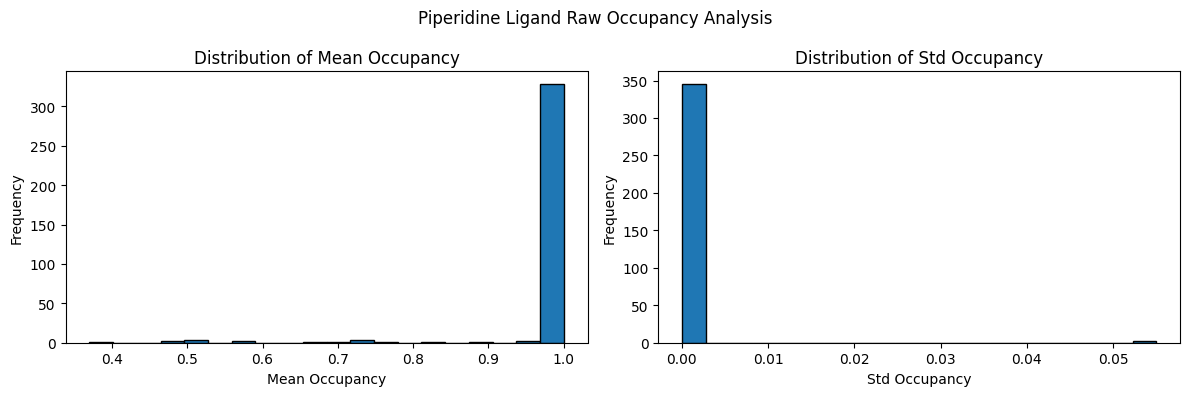

In [186]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ligand_occupancy['mean_occ'], bins=20, edgecolor='black')
axes[0].set_xlabel('Mean Occupancy')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Mean Occupancy')

axes[1].hist(ligand_occupancy['std_occ'], bins=20, edgecolor='black')
axes[1].set_xlabel('Std Occupancy')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Std Occupancy')

plt.suptitle( "Piperidine Ligand Raw Occupancy Analysis")
plt.tight_layout()
plt.show()


### Normalize occupancy of Ligands based off of the corresponding target protein occupancy

<details open>
<summary> Strategy </summary>

- Extract protein object from subset pdb

- Extract atomic b factors

- Calculate mean and std

- Normalize ligand occupancy based off of the protein

</details>

In [187]:
norm_ligand_occ = {
    "dataset_name": [],
    
    "prot_atomic_occ": [],
    "prot_mean_occ": [],
    "prot_std_occ": [],
    
    "prot_norm_atomic_occ": [],
    "prot_norm_mean_occ": [],
    "prot_norm_std_occ": [],
    
    "lig_atomic_occ": [],
    "lig_mean_occ": [],
    "lig_std_occ": [],
    
    "lig_norm_atomic_occ": [],
    "lig_norm_mean_occ": [],
    "lig_norm_std_occ": [],
    
}

for dataset_name, lig_struct in lst_piperids.items():
    pdb_path = piperid_dir / dataset_name / f"{dataset_name}.pdb"
    full_struct = loadPDB(pdb_path)

    # Protein
    protein_struct = sele_pdb(full_struct, sele_AA)
    prot_atoms = flatten_pdb(protein_struct, "atom")
    
    prot_occs = [a.occ for a in prot_atoms]
    prot_mean = float(np.mean(prot_occs))
    prot_std = float(np.std(prot_occs))

    # prot_norm_occs = [(b - prot_mean) / prot_std for b in prot_occs]
    # prot_norm_mean = float(np.mean(prot_norm_occs))
    # prot_norm_std = float(np.std(prot_norm_occs))

    # Ligand
    lig_atoms = flatten_pdb(lig_struct, "atom")
    lig_occs = [a.occ for a in lig_atoms]
    lig_mean = float(np.mean(lig_occs))
    lig_std = float(np.std(lig_occs))

    # # Ligand normalized by protein
    # lig_norm_occs = [(b - prot_mean) / prot_std if prot_std != 0 else 0 for b in lig_occs]
    # lig_norm_mean = float(np.mean(lig_norm_occs))
    # lig_norm_std = float(np.std(lig_norm_occs))


    norm_ligand_occ["dataset_name"].append(dataset_name)

    norm_ligand_occ["prot_atomic_occ"].append(prot_occs)
    norm_ligand_occ["prot_mean_occ"].append(prot_mean)
    norm_ligand_occ["prot_std_occ"].append(prot_std)
    
    # norm_ligand_occ["prot_norm_atomic_occ"].append(prot_norm_occs)
    # norm_ligand_occ["prot_norm_mean_occ"].append(prot_norm_mean)
    # norm_ligand_occ["prot_norm_std_occ"].append(prot_norm_std)
    
    norm_ligand_occ["lig_atomic_occ"].append(lig_occs)
    norm_ligand_occ["lig_mean_occ"].append(lig_mean)
    norm_ligand_occ["lig_std_occ"].append(lig_std)
    
    # norm_ligand_occ["lig_norm_atomic_occ"].append(lig_norm_occs)
    # norm_ligand_occ["lig_norm_mean_occ"].append(lig_norm_mean)
    # norm_ligand_occ["lig_norm_std_occ"].append(lig_norm_std)
    


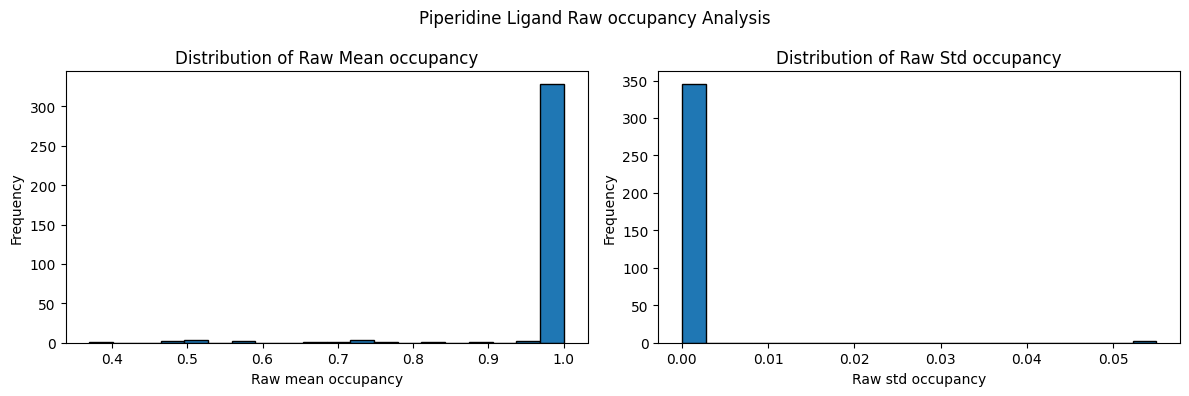

In [188]:
# Plot normalized mean and std occupancy
norm_means = norm_ligand_occ["lig_mean_occ"]
norm_stds = norm_ligand_occ["lig_std_occ"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(norm_means, bins=20, edgecolor='black')
axes[0].set_xlabel('Raw mean occupancy')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Raw Mean occupancy')

axes[1].hist(norm_stds, bins=20, edgecolor='black')
axes[1].set_xlabel('Raw std occupancy')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Raw Std occupancy')

plt.suptitle("Piperidine Ligand Raw occupancy Analysis")
plt.tight_layout()
plt.show()

In [189]:
# # Plot normalized mean and std occupancy
# norm_means = norm_ligand_occ["lig_norm_mean_occ"]
# norm_stds = norm_ligand_occ["lig_norm_std_occ"]

# fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# axes[0].hist(norm_means, bins=20, edgecolor='black')
# axes[0].set_xlabel('Normalized meanoccupancy')
# axes[0].set_ylabel('Frequency')
# axes[0].set_title('Distribution of Normalized Mean occupancy')

# axes[1].hist(norm_stds, bins=20, edgecolor='black')
# axes[1].set_xlabel('Normalized stdoccupancy')
# axes[1].set_ylabel('Frequency')
# axes[1].set_title('Distribution of Normalized Std occupancy')

# plt.suptitle("Piperidine Ligand Normalized occupancy Analysis")
# plt.tight_layout()
plt.show()

In [190]:
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # Histogram for mean occupancy
# axes[0].hist(norm_ligand_occ['lig_mean_occ'], bins=20, alpha=0.6, label='Raw Meanoccupancy', edgecolor='black')
# axes[0].hist(norm_ligand_occ['lig_norm_mean_occ'], bins=20, alpha=0.6, label='Normalized Meanoccupancy', edgecolor='black')
# axes[0].set_xlabel('Meanoccupancy')
# axes[0].set_ylabel('Frequency')
# axes[0].set_title('Raw vs Normalized Mean occupancy')
# axes[0].legend()

# # Histogram for std occupancy
# axes[1].hist(norm_ligand_occ['lig_std_occ'], bins=20, alpha=0.6, label='Raw Stdoccupancy', edgecolor='black')
# axes[1].hist(norm_ligand_occ['lig_norm_std_occ'], bins=20, alpha=0.6, label='Normalized Stdoccupancy', edgecolor='black')
# axes[1].set_xlabel('Stdoccupancy')
# axes[1].set_ylabel('Frequency')
# axes[1].set_title('Raw vs Normalized Std occupancy')
# axes[1].legend()

# plt.suptitle("Comparison of Raw and Normalized Ligand occupancy")
# plt.tight_layout()
# plt.show()

Protein VS Ligand Correlation Analysis

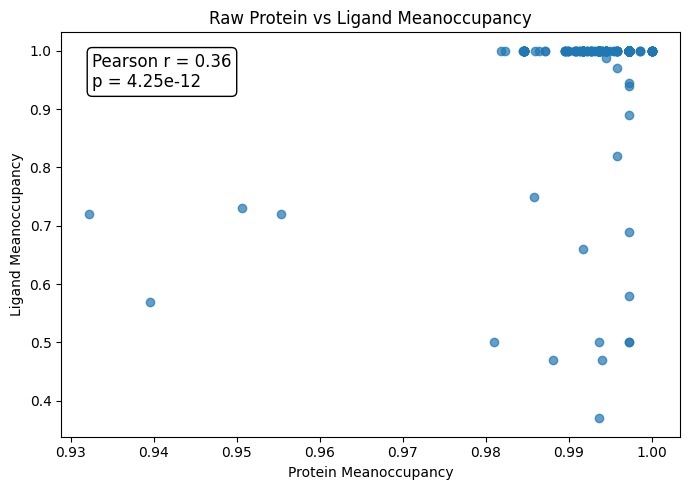

In [191]:
from scipy.stats import pearsonr
# Extract protein and ligand mean occupancy
protein_means = norm_ligand_occ["prot_mean_occ"]
ligand_means = norm_ligand_occ["lig_mean_occ"]

# Scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(protein_means, ligand_means, alpha=0.7)
plt.xlabel("Protein Meanoccupancy")
plt.ylabel("Ligand Meanoccupancy")
plt.title("Raw Protein vs Ligand Meanoccupancy")

# Pearson correlation
corr, pval = pearsonr(protein_means, ligand_means)
plt.annotate(f"Pearson r = {corr:.2f}\np = {pval:.2e}", 
             xy=(0.05, 0.95), xycoords='axes fraction', 
             ha='left', va='top', fontsize=12, bbox=dict(boxstyle="round", fc="w"))

plt.tight_layout()
plt.show()

In [192]:
# from scipy.stats import pearsonr

# # Extract protein and ligand mean occupancy
# protein_means = norm_ligand_occ["prot_norm_mean_occ"]
# ligand_means = norm_ligand_occ["lig_norm_mean_occ"]

# # Scatter plot
# plt.figure(figsize=(7, 5))
# plt.scatter(protein_means, ligand_means, alpha=0.7)
# plt.xlabel("Protein Meanoccupancy")
# plt.ylabel("Ligand Meanoccupancy")
# plt.title("Normalized Protein vs Ligand Meanoccupancy")

# # Pearson correlation
# corr, pval = pearsonr(protein_means, ligand_means)
# plt.annotate(f"Pearson r = {corr:.2f}\np = {pval:.2e}", 
#              xy=(0.05, 0.95), xycoords='axes fraction', 
#              ha='left', va='top', fontsize=12, bbox=dict(boxstyle="round", fc="w"))

# plt.tight_layout()
# plt.show()

### Ligand VS IC50 Correlations

In [193]:
import pandas as pd
import re

metadata_df = pd.read_csv( str(rootdir.joinpath( r"data/ev2a/fragalysis/01-concatDir/metadata.csv") ) )
cdd_df = pd.read_csv( rootdir.joinpath(r"data/ev2a/cdd/cdd_v3.csv"))


regex = re.compile( "weizmann")
new_columns_names = [ col if not regex.search(col) else "WEIZMAN" + col[regex.search(col).end():] for col in  cdd_df.columns.to_list() ]
regex = re.compile( "bienta")
new_columns_names = [ col if not regex.search(col) else "BIENTA" + col[regex.search(col).end():] for col in  new_columns_names]
regex = re.compile( "X-ray_Diamond")
new_columns_names = [ col if not regex.search(col) else "X-RAY"+ col[regex.search(col).end():] for col in  new_columns_names]
cdd_df.columns = new_columns_names


piperidine_df = metadata_df[ (metadata_df[ "[Series] Piperidine series"]==True ) ] # Select piperidine entries only
piperidine_singles_df = piperidine_df[ 
                        [ not (code [:-1] + "b" in piperidine_df["Code"].values) 
                        for code in piperidine_df["Code"].values ] 
                        ]  # Select datasets with single entries only (i.e., A1259a but not A1259b, ...c, etc)
piperidine_singles_df = piperidine_singles_df[ 
                        [ len( piperidine_singles_df[piperidine_singles_df["Experiment code"] == code ] ) == 1 
                        for code in piperidine_singles_df["Experiment code"] ] ] # Double check single entry datasets only (i.e., A71EV2A-x1292 with only one entry)

pip_exp_codes = piperidine_singles_df[ [ "Experiment code"]].values.flatten()
pip_exp_codes.sort()

pip_cdd_df =  cdd_df[ cdd_df["X-RAY: Dataset"].isin( pip_exp_codes ) ]

cdd_molecname_for_frag= [ list(pip_cdd_df[ pip_cdd_df["X-RAY: Dataset"] == expcode ]["Molecule Name"].unique())[0]
        if len( pip_cdd_df[ pip_cdd_df["X-RAY: Dataset"] == expcode ]["Molecule Name"].unique() ) != 0
        else None
        for expcode in piperidine_singles_df["Experiment code"]   ]

piperidine_singles_df.insert(0, "CDD Molecule Name",cdd_molecname_for_frag)

def is_convertible_to_float( obj) -> bool:
    """
    Checks if a string 's' can be safely converted to a float.
    Returns True if convertible, False otherwise.
    """
    try:
        float(obj)
        return True
    except ValueError:
        return False

cdd_ic50_for_frag= [ 
        pip_cdd_df[ pip_cdd_df["Molecule Name"] == molecName ]["WEIZMAN: IC50_GMean (µM)"].unique()[0]
          if ( len( pip_cdd_df[ pip_cdd_df["Molecule Name"] == molecName ]["WEIZMAN: IC50_GMean (µM)"].unique() ) != 0
              and is_convertible_to_float( pip_cdd_df[ pip_cdd_df["Molecule Name"] == molecName ]["WEIZMAN: IC50_GMean (µM)"].unique()[0] ))
    else pip_cdd_df[ pip_cdd_df["Molecule Name"] == molecName ]["BIENTA: IC50_GMean (µM)"].unique()[0]
          if ( len( pip_cdd_df[ pip_cdd_df["Molecule Name"] == molecName ]["BIENTA: IC50_GMean (µM)"].unique() ) != 0
              and is_convertible_to_float( pip_cdd_df[ pip_cdd_df["Molecule Name"] == molecName ]["BIENTA: IC50_GMean (µM)"].unique()[0] ))
        else None
        for _, molecName in piperidine_singles_df[["Experiment code","CDD Molecule Name"]].values   ]

piperidine_singles_df.insert(1, "CDD Mean IC 50",cdd_ic50_for_frag)
# display( piperidine_singles_df[piperidine_singles_df["CDD Mean IC 50"].notna()].head(5) )
# display( piperidine_singles_df.sort_values("CDD Mean IC 50").iloc[ :, :65].head(5) )

piperidine_dataset_codes = piperidine_singles_df[piperidine_singles_df["CDD Mean IC 50"].notna()]["Code"].tolist()
piperidine_ic50_values = piperidine_singles_df[piperidine_singles_df["CDD Mean IC 50"].notna()]["CDD Mean IC 50"].tolist()
piperidine_ic50_values = np.array( [ float( ic50 ) for ic50 in piperidine_ic50_values ] )
# print( "Number of Piperidine Datasets with IC 50 values: ", len(piperidine_dataset_codes) )

In [194]:
pip_codes = set( [ code[:-1] for code in piperidine_dataset_codes] )

pip_codes_w_ic50 = sorted( [ code for code in norm_ligand_occ["dataset_name"] if code[:-1] in pip_codes  ] )
pip_codes_w_ic50_prefix = set( [code[:-1] for code in pip_codes_w_ic50])

pip_ic50 = [ ( code , ic50) for code, ic50 in zip( piperidine_dataset_codes, piperidine_ic50_values ) if code[:-1] in pip_codes_w_ic50_prefix ]
# print( pip_ic50)
# print( len( pip_codes) )
# print( pip_codes_w_ic50 )

In [195]:
lst_data = []
for code, ic50 in pip_ic50:
    # print( code)
    for dataset_name,raw_occ in zip( norm_ligand_occ["dataset_name"], norm_ligand_occ["lig_mean_occ"],):# norm_ligand_occ["lig_norm_mean_occ"]):
        if code == dataset_name:
            lst_data.append( (code, raw_occ, ic50))# norm_occ, ic50))

codes, raw_occ, ic50 = zip( *lst_data) # norm_occ, ic50 = zip( *lst_data)

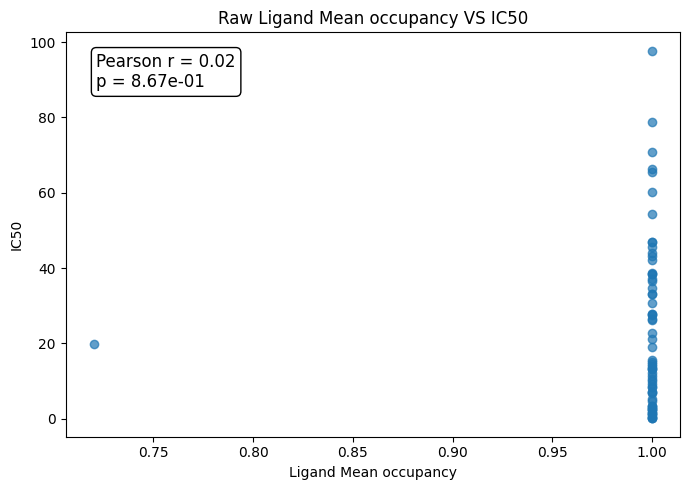

In [196]:
from scipy.stats import pearsonr

# Extract protein and ligand mean occupancy
ligand_means = norm_ligand_occ["lig_norm_mean_occ"]

# Scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(raw_occ, ic50, alpha=0.7)
plt.xlabel("Ligand Mean occupancy")
plt.ylabel("IC50")
plt.title("Raw Ligand Mean occupancy VS IC50")

# Pearson correlation
corr, pval = pearsonr(raw_occ, ic50)
plt.annotate(f"Pearson r = {corr:.2f}\np = {pval:.2e}", 
             xy=(0.05, 0.95), xycoords='axes fraction', 
             ha='left', va='top', fontsize=12, bbox=dict(boxstyle="round", fc="w"))

plt.tight_layout()
plt.show()

In [197]:
# from scipy.stats import pearsonr

# # Extract protein and ligand mean occupancy
# ligand_means = norm_ligand_occ["lig_norm_mean_occ"]

# # Scatter plot
# plt.figure(figsize=(7, 5))
# plt.scatter(norm_occ, ic50, alpha=0.7)
# plt.xlabel("Ligand Meanoccupancy")
# plt.ylabel("IC50")
# plt.title("Normalized Ligand Meanoccupancy VS IC50")

# # Pearson correlation
# corr, pval = pearsonr(norm_occ, ic50)
# plt.annotate(f"Pearson r = {corr:.2f}\np = {pval:.2e}", 
#              xy=(0.05, 0.95), xycoords='axes fraction', 
#              ha='left', va='top', fontsize=12, bbox=dict(boxstyle="round", fc="w"))

# plt.tight_layout()
# plt.show()